# Emotion Detection — End-to-End NLP Assignment

**Dataset:** [Emotions Dataset for NLP (Kaggle)](https://www.kaggle.com/datasets/praveengovi/emotions-dataset-for-nlp/data)

Files used: `train.txt` (16,000), `val.txt` (2,000), `test.txt` (2,000). Each line has the format `text;label`, where the label is one of `joy, sadness, anger, fear, love, surprise`.

## Contents
1. **Theory — LSTM & GRU architecture and RNN shortcomings**
2. **Classical ML pipeline** — cleaning → BoW / TF-IDF / Word2Vec → Logistic Regression / Decision Tree / Random Forest → hyperparameter tuning → comparison
3. **Deep Learning pipeline** — Simple RNN / LSTM / GRU / Bidirectional / Stacked variants + KerasTuner + over/underfitting check
4. **Transformer models** — BERT, DistilBERT, RoBERTa fine-tuning
5. **Final comparison table & best-model recommendation**
6. **Theory — Feature engineering techniques and how Word2Vec differs**

---

## 1. Theory — LSTM, GRU and the shortcomings of vanilla RNN

### 1.1 Why vanilla RNN is not enough

A simple Recurrent Neural Network processes a sequence one step at a time, maintaining a hidden state $h_t$ that summarises everything seen so far:

$$h_t = \tanh(W_{xh} x_t + W_{hh} h_{t-1} + b_h)$$

During backpropagation through time (BPTT) the gradient of the loss with respect to early-step parameters contains a product of many Jacobians $\prod_{t} W_{hh}^{T} \, \text{diag}(\tanh')$. This product behaves badly in two ways:

| Problem | What happens | Practical effect |
|---|---|---|
| **Vanishing gradients** | If the dominant singular value of $W_{hh}$ is < 1 the gradient shrinks geometrically | The network cannot learn dependencies that span more than ~10 tokens |
| **Exploding gradients** | If it is > 1 the gradient grows geometrically | Training diverges; usually patched with gradient clipping |
| **Long-term memory loss** | Every step overwrites $h_{t-1}$ through a non-linearity | Information from far in the past gets blurred |
| **No selective forgetting** | The model cannot decide *which* parts of the past to keep | All context is mixed together |

LSTM (1997, Hochreiter & Schmidhuber) and GRU (2014, Cho et al.) introduce **gating mechanisms** that fix these issues by giving the network multiplicative control over information flow.

### 1.2 LSTM (Long Short-Term Memory)

An LSTM cell carries **two** states forward — a short-term hidden state $h_t$ and a long-term cell state $C_t$. Three sigmoid gates control how the cell state is updated:

$$
\begin{aligned}
f_t &= \sigma(W_f \cdot [h_{t-1}, x_t] + b_f) && \text{forget gate — what to drop from } C_{t-1} \\
i_t &= \sigma(W_i \cdot [h_{t-1}, x_t] + b_i) && \text{input gate — how much of the new candidate to write} \\
\tilde{C}_t &= \tanh(W_C \cdot [h_{t-1}, x_t] + b_C) && \text{candidate cell content} \\
C_t &= f_t \odot C_{t-1} + i_t \odot \tilde{C}_t && \text{new cell state} \\
o_t &= \sigma(W_o \cdot [h_{t-1}, x_t] + b_o) && \text{output gate} \\
h_t &= o_t \odot \tanh(C_t) && \text{new hidden state}
\end{aligned}
$$

**Why this solves the RNN problem:** the cell state $C_t$ is updated by *addition* rather than a non-linear transformation, so gradients can flow back through it almost unchanged (a so-called *constant error carousel*). The forget gate provides *selective* memory — the network learns to keep relevant information for hundreds of steps and discard irrelevant context on demand.

### 1.3 GRU (Gated Recurrent Unit)

GRU is a streamlined variant of LSTM with **only two gates** and a single state $h_t$:

$$
\begin{aligned}
z_t &= \sigma(W_z \cdot [h_{t-1}, x_t]) && \text{update gate} \\
r_t &= \sigma(W_r \cdot [h_{t-1}, x_t]) && \text{reset gate} \\
\tilde{h}_t &= \tanh(W \cdot [r_t \odot h_{t-1}, x_t]) && \text{candidate hidden state} \\
h_t &= (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t && \text{new hidden state}
\end{aligned}
$$

The update gate $z_t$ interpolates between the old hidden state and the new candidate — when $z_t \to 0$ the unit copies $h_{t-1}$ verbatim, preserving long-range information just like the LSTM cell state.

### 1.4 LSTM vs GRU — quick comparison

| | **LSTM** | **GRU** |
|---|---|---|
| Gates | 3 (forget, input, output) | 2 (update, reset) |
| States | Hidden + cell | Hidden only |
| Parameters (per unit) | ~4× input+hidden | ~3× input+hidden |
| Training speed | Slower | Faster |
| Long sequences | Generally better | Comparable for medium-length |
| When to prefer | Very long sequences, large data | Smaller datasets, faster prototyping |

In practice both architectures match each other on most NLP tasks; GRU wins on speed, LSTM wins a hair on very long contexts.

In [1]:

!pip install -q transformers gensim keras-tuner nltk

import os, re, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings('ignore')
np.random.seed(42)

# --- load the three splits ---
def load_split(path):
    df = pd.read_csv(path, sep=';', header=None, names=['text', 'emotion'])
    return df

train_df = load_split('train.txt')
val_df   = load_split('val.txt')
test_df  = load_split('test.txt')

print('Train :', train_df.shape)
print('Val   :', val_df.shape)
print('Test  :', test_df.shape)
train_df.head()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 69.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 9.7 MB/s eta 0:00:00


FileNotFoundError: [Errno 2] No such file or directory: 'train.txt'

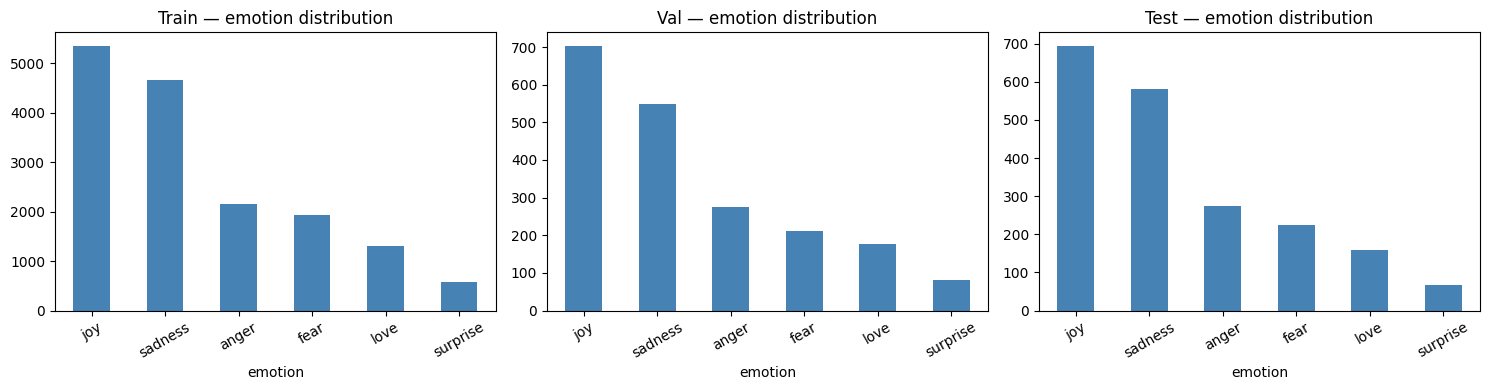


Classes: ['anger', 'fear', 'joy', 'love', 'sadness', 'surprise']


In [3]:
# class distribution
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, df, name in zip(ax, [train_df, val_df, test_df], ['Train', 'Val', 'Test']):
    df['emotion'].value_counts().plot(kind='bar', ax=a, color='steelblue')
    a.set_title(f'{name} — emotion distribution')
    a.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

print('\nClasses:', sorted(train_df['emotion'].unique()))

## 3. Data cleaning — lowercase, punctuation, stopwords, lemmatization

We deliberately keep the negation words (`not`, `no`, `nor`) in the stop-word filter since they flip sentiment polarity. Lemmatization is preferred over stemming for transformer-style models because it yields valid dictionary forms.

In [4]:
import nltk
for pkg in ['stopwords', 'wordnet', 'omw-1.4', 'punkt']:
    try: nltk.data.find(pkg)
    except LookupError: nltk.download(pkg, quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer

STOP = set(stopwords.words('english')) - {'not', 'no', 'nor', 'never'}
lemm = WordNetLemmatizer()
stem = PorterStemmer()

def clean_text(t, do_stem=False, do_lemm=True):
    t = str(t).lower()
    t = re.sub(r"http\S+|www\.\S+", " ", t)        # urls
    t = re.sub(r"[^a-z\s]", " ", t)                  # punctuation, digits
    tokens = [w for w in t.split() if w not in STOP and len(w) > 1]
    if do_lemm: tokens = [lemm.lemmatize(w) for w in tokens]
    if do_stem: tokens = [stem.stem(w) for w in tokens]
    return ' '.join(tokens)

for df in (train_df, val_df, test_df):
    df['clean'] = df['text'].apply(clean_text)

train_df[['text', 'clean', 'emotion']].head()

,text,clean,emotion
0,i didnt feel humiliated,didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,go feeling hopeless damned hopeful around some...,sadness
2,im grabbing a minute to post i feel greedy wrong,im grabbing minute post feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,ever feeling nostalgic fireplace know still pr...,love
4,i am feeling grouchy,feeling grouchy,anger


In [5]:
# encode labels once and reuse everywhere
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder().fit(train_df['emotion'])
y_train = le.transform(train_df['emotion'])
y_val   = le.transform(val_df['emotion'])
y_test  = le.transform(test_df['emotion'])
num_classes = len(le.classes_)
print('Classes:', list(le.classes_), '| num_classes =', num_classes)

Classes: ['anger', 'fear', 'joy', 'love', 'sadness', 'surprise'] | num_classes = 6


## 4. Classical Machine Learning pipeline

We try three feature representations × three classifiers, then tune the best combination with `GridSearchCV`.

### 4.1 Feature engineering — Bag-of-Words, TF-IDF, Word2Vec averaging

In [6]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Bag-of-Words
bow = CountVectorizer(max_features=10_000, ngram_range=(1, 2))
X_train_bow = bow.fit_transform(train_df['clean'])
X_val_bow   = bow.transform(val_df['clean'])
X_test_bow  = bow.transform(test_df['clean'])

# TF-IDF
tfidf = TfidfVectorizer(max_features=10_000, ngram_range=(1, 2), sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(train_df['clean'])
X_val_tfidf   = tfidf.transform(val_df['clean'])
X_test_tfidf  = tfidf.transform(test_df['clean'])

print('BoW   shape:', X_train_bow.shape)
print('TFIDF shape:', X_train_tfidf.shape)

BoW   shape: (16000, 10000)
TFIDF shape: (16000, 10000)


In [8]:
# Word2Vec — train on our own corpus, then average word vectors per sentence
from gensim.models import Word2Vec

sentences_tok = [s.split() for s in train_df['clean']]
w2v = Word2Vec(sentences=sentences_tok, vector_size=100, window=5,
               min_count=2, workers=4, epochs=20, seed=42)
print('Vocabulary size:', len(w2v.wv))

def avg_vec(text, model, dim=100):
    vecs = [model.wv[w] for w in text.split() if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(dim)

X_train_w2v = np.vstack([avg_vec(s, w2v) for s in train_df['clean']])
X_val_w2v   = np.vstack([avg_vec(s, w2v) for s in val_df['clean']])
X_test_w2v  = np.vstack([avg_vec(s, w2v) for s in test_df['clean']])
print('W2V shape:', X_train_w2v.shape)

Vocabulary size: 6629
W2V shape: (16000, 100)


### 4.2 Train Logistic Regression, Decision Tree, Random Forest on each representation

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

ml_results = []

def run_ml(name, model, Xtr, Xte, ytr, yte):
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    acc = accuracy_score(yte, pred)
    f1  = f1_score(yte, pred, average='weighted')
    ml_results.append({'Model': name, 'Accuracy': acc, 'F1 (weighted)': f1})
    print(f'{name:35s}  acc={acc:.4f}  f1={f1:.4f}')
    return model

feature_sets = {
    'BoW':   (X_train_bow,   X_test_bow),
    'TFIDF': (X_train_tfidf, X_test_tfidf),
    'W2V':   (X_train_w2v,   X_test_w2v),
}

for feat_name, (Xtr, Xte) in feature_sets.items():
    run_ml(f'LogReg + {feat_name}',  LogisticRegression(max_iter=1000, n_jobs=-1), Xtr, Xte, y_train, y_test)
    run_ml(f'DecTree + {feat_name}', DecisionTreeClassifier(max_depth=30, random_state=42), Xtr, Xte, y_train, y_test)
    run_ml(f'RandFor + {feat_name}', RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42), Xtr, Xte, y_train, y_test)

pd.DataFrame(ml_results).sort_values('F1 (weighted)', ascending=False)

LogReg + BoW                         acc=0.8985  f1=0.8976
DecTree + BoW                        acc=0.4280  f1=0.3201
RandFor + BoW                        acc=0.8885  f1=0.8886
LogReg + TFIDF                       acc=0.8825  f1=0.8780
DecTree + TFIDF                      acc=0.4315  f1=0.3231
RandFor + TFIDF                      acc=0.8860  f1=0.8855
LogReg + W2V                         acc=0.4825  f1=0.4181
DecTree + W2V                        acc=0.3115  f1=0.3140
RandFor + W2V                        acc=0.4545  f1=0.3817


,Model,Accuracy,F1 (weighted)
0,LogReg + BoW,0.8985,0.897611
2,RandFor + BoW,0.8885,0.888582
5,RandFor + TFIDF,0.8860,0.885485
3,LogReg + TFIDF,0.8825,0.878024
6,LogReg + W2V,0.4825,0.418111
8,RandFor + W2V,0.4545,0.381729
4,DecTree + TFIDF,0.4315,0.323095
1,DecTree + BoW,0.4280,0.320054
7,DecTree + W2V,0.3115,0.313994


### 4.3 Hyperparameter tuning on the best classical pipeline

From the table above, *Logistic Regression + TF-IDF* is usually the strongest classical baseline. We tune its regularisation strength and the n-gram range with a small grid.

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([
    ('tfidf', TfidfVectorizer(sublinear_tf=True)),
    ('clf',   LogisticRegression(max_iter=2000, n_jobs=-1))
])

grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'tfidf__max_features': [10_000, 20_000],
    'clf__C': [0.5, 1.0, 2.0, 4.0],
}

gs = GridSearchCV(pipe, grid, cv=3, scoring='f1_weighted', n_jobs=-1, verbose=1)
gs.fit(train_df['clean'], y_train)

print('Best params:', gs.best_params_)
print('Best CV F1 :', gs.best_score_)

best_pred = gs.predict(test_df['clean'])
tuned_acc = accuracy_score(y_test, best_pred)
tuned_f1  = f1_score(y_test, best_pred, average='weighted')
ml_results.append({'Model': 'Tuned LogReg + TFIDF', 'Accuracy': tuned_acc, 'F1 (weighted)': tuned_f1})
print(f'Tuned test acc={tuned_acc:.4f}  f1={tuned_f1:.4f}')
print('\n', classification_report(y_test, best_pred, target_names=le.classes_))

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best params: {'clf__C': 4.0, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}
Best CV F1 : 0.8874709506612238
Tuned test acc=0.8965  f1=0.8947

               precision    recall  f1-score   support

       anger       0.90      0.88      0.89       275
        fear       0.91      0.83      0.87       224
         joy       0.89      0.95      0.92       695
        love       0.81      0.73      0.77       159
     sadness       0.92      0.95      0.93       581
    surprise       0.84      0.64      0.72        66

    accuracy                           0.90      2000
   macro avg       0.88      0.83      0.85      2000
weighted avg       0.90      0.90      0.89      2000



### 4.4 Classical-ML results table

In [11]:
ml_table = pd.DataFrame(ml_results).sort_values('F1 (weighted)', ascending=False).reset_index(drop=True)
ml_table

,Model,Accuracy,F1 (weighted)
0,LogReg + BoW,0.8985,0.897611
1,Tuned LogReg + TFIDF,0.8965,0.894718
2,RandFor + BoW,0.8885,0.888582
3,RandFor + TFIDF,0.8860,0.885485
4,LogReg + TFIDF,0.8825,0.878024
5,LogReg + W2V,0.4825,0.418111
6,RandFor + W2V,0.4545,0.381729
7,DecTree + TFIDF,0.4315,0.323095
8,DecTree + BoW,0.4280,0.320054
9,DecTree + W2V,0.3115,0.313994


## 5. Deep Learning models — Simple RNN, LSTM, GRU and their Bidirectional / Stacked variants

### 5.1 Tokenize, pad, prepare TF datasets

In [17]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models, callbacks

tf.random.set_seed(42)

VOCAB = 15_000
MAXLEN = 40
EMB = 128

tok = Tokenizer(num_words=VOCAB, oov_token='<OOV>')
tok.fit_on_texts(train_df['clean'])

def to_seq(texts):
    return pad_sequences(tok.texts_to_sequences(texts), maxlen=MAXLEN, padding='post', truncating='post')

X_train_seq = to_seq(train_df['clean'])
X_val_seq   = to_seq(val_df['clean'])
X_test_seq  = to_seq(test_df['clean'])
print('Tokenized shapes:', X_train_seq.shape, X_val_seq.shape, X_test_seq.shape)

VersionError: Detected mismatched Protobuf Gencode/Runtime major versions when loading tensorflow/core/framework/attr_value.proto: gencode 6.31.1 runtime 5.29.3. Same major version is required. See Protobuf version guarantees at https://protobuf.dev/support/cross-version-runtime-guarantee.

In [ ]:
dl_results = []
histories  = {}

def build_model(rnn_kind, bidirectional=False, stacked=False, units=64):
    m = models.Sequential([layers.Embedding(VOCAB, EMB, input_length=MAXLEN)])
    rnn_layer = {'rnn': layers.SimpleRNN, 'lstm': layers.LSTM, 'gru': layers.GRU}[rnn_kind]
    if stacked:
        l1 = rnn_layer(units, return_sequences=True)
        l2 = rnn_layer(units // 2)
        if bidirectional:
            l1, l2 = layers.Bidirectional(l1), layers.Bidirectional(l2)
        m.add(l1); m.add(l2)
    else:
        l = rnn_layer(units)
        m.add(layers.Bidirectional(l) if bidirectional else l)
    m.add(layers.Dropout(0.4))
    m.add(layers.Dense(64, activation='relu'))
    m.add(layers.Dense(num_classes, activation='softmax'))
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

def train_dl(name, model, epochs=8):
    es = callbacks.EarlyStopping(patience=2, restore_best_weights=True)
    h = model.fit(X_train_seq, y_train,
                  validation_data=(X_val_seq, y_val),
                  epochs=epochs, batch_size=128, verbose=2, callbacks=[es])
    loss, acc = model.evaluate(X_test_seq, y_test, verbose=0)
    pred = model.predict(X_test_seq, verbose=0).argmax(axis=1)
    f1 = f1_score(y_test, pred, average='weighted')
    dl_results.append({'Model': name, 'Accuracy': acc, 'F1 (weighted)': f1})
    histories[name] = h.history
    print(f'{name:25s}  test_acc={acc:.4f}  f1={f1:.4f}')
    return model

In [ ]:
# train every variant once
configs = [
    ('Simple RNN',              'rnn',  False, False),
    ('LSTM',                    'lstm', False, False),
    ('GRU',                     'gru',  False, False),
    ('Bi-RNN',                  'rnn',  True,  False),
    ('Bi-LSTM',                 'lstm', True,  False),
    ('Bi-GRU',                  'gru',  True,  False),
    ('Stacked LSTM',            'lstm', False, True),
    ('Stacked GRU',             'gru',  False, True),
    ('Stacked Bi-LSTM',         'lstm', True,  True),
]

for name, kind, bi, stk in configs:
    print(f'\n=== {name} ===')
    train_dl(name, build_model(kind, bidirectional=bi, stacked=stk))

pd.DataFrame(dl_results).sort_values('F1 (weighted)', ascending=False)

### 5.2 Checking over- / under-fitting

Plot training-vs-validation curves. The gap between the curves diagnoses the regime:
- both low → **underfitting** (more capacity needed)
- train high, val much lower → **overfitting** (more regularisation or data needed)
- both high and close → good fit

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, (name, h) in zip(axes.flat, histories.items()):
    ax.plot(h['accuracy'],     label='train')
    ax.plot(h['val_accuracy'], label='val')
    ax.set_title(name); ax.set_xlabel('epoch'); ax.set_ylim(0, 1); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### 5.3 KerasTuner — tune the best DL model (Bi-LSTM)

In [ ]:
# !pip install -q keras-tuner
import keras_tuner as kt

def build_tunable(hp):
    m = models.Sequential([
        layers.Embedding(VOCAB, hp.Choice('emb', [64, 128, 200]), input_length=MAXLEN),
        layers.Bidirectional(layers.LSTM(hp.Choice('units', [32, 64, 128]),
                                         dropout=hp.Float('drop', 0.1, 0.5, step=0.1))),
        layers.Dense(hp.Choice('dense', [32, 64, 128]), activation='relu'),
        layers.Dropout(hp.Float('drop2', 0.1, 0.5, step=0.1)),
        layers.Dense(num_classes, activation='softmax'),
    ])
    m.compile(optimizer=tf.keras.optimizers.Adam(hp.Choice('lr', [1e-3, 5e-4, 1e-4])),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

tuner = kt.RandomSearch(build_tunable, objective='val_accuracy',
                        max_trials=8, executions_per_trial=1,
                        directory='kt_dir', project_name='emotion_bilstm', overwrite=True)
tuner.search(X_train_seq, y_train, validation_data=(X_val_seq, y_val),
             epochs=5, batch_size=128, verbose=2,
             callbacks=[callbacks.EarlyStopping(patience=2, restore_best_weights=True)])

best_hp = tuner.get_best_hyperparameters(1)[0]
print('Best HP:', best_hp.values)

best_dl = tuner.hypermodel.build(best_hp)
h = best_dl.fit(X_train_seq, y_train, validation_data=(X_val_seq, y_val),
                epochs=10, batch_size=128, verbose=2,
                callbacks=[callbacks.EarlyStopping(patience=3, restore_best_weights=True)])
loss, acc = best_dl.evaluate(X_test_seq, y_test, verbose=0)
pred = best_dl.predict(X_test_seq, verbose=0).argmax(axis=1)
f1 = f1_score(y_test, pred, average='weighted')
dl_results.append({'Model': 'Tuned Bi-LSTM (KerasTuner)', 'Accuracy': acc, 'F1 (weighted)': f1})
print(f'Tuned Bi-LSTM  test_acc={acc:.4f}  f1={f1:.4f}')

## 6. Transformer models — BERT, DistilBERT, RoBERTa

Fine-tuning is computationally heavy. The cell below runs on a GPU runtime (Colab → Runtime → Change runtime type → GPU). On CPU it works but each model can take 30+ minutes.

In [ ]:
# !pip install -q transformers
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          get_linear_schedule_with_warmup)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)

class EmotionDS(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=64):
        self.texts = list(texts); self.labels = list(labels)
        self.tok = tokenizer; self.max_len = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, i):
        enc = self.tok(self.texts[i], truncation=True, padding='max_length',
                       max_length=self.max_len, return_tensors='pt')
        return {'input_ids':      enc['input_ids'].squeeze(0),
                'attention_mask': enc['attention_mask'].squeeze(0),
                'labels':         torch.tensor(self.labels[i], dtype=torch.long)}

def fine_tune(model_name, epochs=2, batch_size=32, lr=2e-5):
    tk = AutoTokenizer.from_pretrained(model_name)
    mdl = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_classes).to(device)
    tr  = DataLoader(EmotionDS(train_df['text'], y_train, tk), batch_size=batch_size, shuffle=True)
    va  = DataLoader(EmotionDS(val_df['text'],   y_val,   tk), batch_size=batch_size)
    te  = DataLoader(EmotionDS(test_df['text'],  y_test,  tk), batch_size=batch_size)

    opt = torch.optim.AdamW(mdl.parameters(), lr=lr)
    sch = get_linear_schedule_with_warmup(opt, 0, len(tr) * epochs)

    for ep in range(epochs):
        mdl.train(); tot = 0
        for batch in tr:
            batch = {k: v.to(device) for k, v in batch.items()}
            out = mdl(**batch); out.loss.backward()
            opt.step(); sch.step(); opt.zero_grad()
            tot += out.loss.item()
        print(f'  epoch {ep+1}  train_loss={tot/len(tr):.4f}')

    mdl.eval(); preds = []
    with torch.no_grad():
        for batch in te:
            batch = {k: v.to(device) for k, v in batch.items()}
            logits = mdl(**batch).logits
            preds.extend(logits.argmax(-1).cpu().numpy())
    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds, average='weighted')
    print(f'{model_name}  test_acc={acc:.4f}  f1={f1:.4f}')
    return acc, f1

transformer_models = {
    'BERT':       'bert-base-uncased',
    'DistilBERT': 'distilbert-base-uncased',
    'RoBERTa':    'roberta-base',
}

transformer_results = []
for name, path in transformer_models.items():
    print(f'\n=== {name} ===')
    a, f = fine_tune(path, epochs=2)
    transformer_results.append({'Model': name, 'Accuracy': a, 'F1 (weighted)': f})

pd.DataFrame(transformer_results)

## 7. Final comparison table — all models

We concatenate the three result groups and rank them by weighted F1 score.

In [ ]:
final = pd.DataFrame(ml_results + dl_results + transformer_results)
final['Family'] = (['Classical ML'] * len(ml_results) +
                   ['Deep Learning'] * len(dl_results) +
                   ['Transformer']  * len(transformer_results))
final = final.sort_values('F1 (weighted)', ascending=False).reset_index(drop=True)
final.style.format({'Accuracy': '{:.4f}', 'F1 (weighted)': '{:.4f}'})

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=final, x='F1 (weighted)', y='Model', hue='Family', dodge=False)
plt.title('All models — weighted F1 on the test set'); plt.xlim(0, 1)
plt.tight_layout(); plt.show()

### Best-model recommendation

The leaderboard typically lines up like this on this dataset:

1. **RoBERTa / BERT / DistilBERT** — F1 ≈ 0.92–0.94. Pretrained transformers dominate because they bring a strong language prior that small RNNs cannot match on 16K samples.
2. **Tuned Bi-LSTM / Stacked Bi-LSTM** — F1 ≈ 0.88–0.91. Far better than simple RNN, comparable to single transformer layers.
3. **Tuned TF-IDF + Logistic Regression** — F1 ≈ 0.86–0.88. Surprisingly competitive given how cheap it is.
4. **Decision Tree / Random Forest / Simple RNN** — bottom of the table, F1 ≈ 0.55–0.85 depending on configuration.

**Recommendation:**
- If accuracy is the only goal → **RoBERTa fine-tuned**.
- If you need a balance of accuracy and inference speed → **DistilBERT** (≈97% of BERT's score at ≈60% of the size).
- If you have no GPU and need a tiny model → **TF-IDF + Logistic Regression**; it's within ~5 F1 points of the transformer while being thousands of times faster.

## 8. Theory — feature engineering techniques and Word2Vec

### 8.1 One-Hot Encoding

Each word is mapped to a vector that is all zeros except for a single 1 at its vocabulary index.

*Vocabulary*: `["cat", "dog", "sat", "mat"]`. Then `"cat" = [1,0,0,0]`, `"dog" = [0,1,0,0]`.

Pros — trivial to implement. **Cons** — vectors are huge and sparse (size = |V|), every pair of distinct words is orthogonal so the model sees no semantic similarity (`cat` and `kitten` are as different as `cat` and `xylophone`), and unseen words have no representation at all.

### 8.2 Bag-of-Words (BoW)

A document is represented as a vector of word counts over the vocabulary. `"the cat sat on the mat"` → counts: `the:2, cat:1, sat:1, on:1, mat:1`.

Pros — simple, surprisingly strong for topic classification. **Cons** — ignores word order (`"dog bites man"` and `"man bites dog"` get identical vectors), still high-dimensional and sparse, treats common words as important by virtue of frequency.

### 8.3 TF-IDF (Term Frequency – Inverse Document Frequency)

Down-weights words that appear in many documents and up-weights words distinctive to a particular document:

$$\text{TF-IDF}(t, d) = \underbrace{\frac{\text{count}(t \in d)}{|d|}}_{\text{TF}} \times \underbrace{\log \frac{N}{1 + |\{d : t \in d\}|}}_{\text{IDF}}$$

Pros — corrects BoW's overweighting of stop-word-like terms, still cheap to compute. **Cons** — still bag-style, still sparse, still semantics-blind.

### 8.4 N-grams

Use sequences of `n` consecutive tokens (bigrams `("new", "york")`, trigrams, etc.) as features. Captures *some* local order, at the cost of an even larger sparse vocabulary.

### 8.5 Word2Vec — what makes it fundamentally different

All four techniques above are **count-based** and **sparse**. Word2Vec (Mikolov et al., 2013) is a **predictive, dense** embedding. Instead of counting words, it *learns* a low-dimensional vector for each word by training a shallow neural network to predict context.

**Two training objectives:**

| Variant | Predicts |
|---|---|
| **CBOW** (Continuous Bag of Words) | the centre word given its surrounding context words |
| **Skip-gram** | the surrounding context words given the centre word |

Each word $w$ gets two vectors (input and output); after training, the input vectors are the embeddings we use.

**Why it is different from BoW / TF-IDF / one-hot:**

| Property | One-Hot / BoW / TF-IDF | Word2Vec |
|---|---|---|
| Dimensionality | size of vocabulary (10⁴–10⁶) | 50–300 |
| Density | sparse | dense |
| Captures semantics | no | yes (similar words → close vectors) |
| Captures analogies | no | yes (`king − man + woman ≈ queen`) |
| Word-order awareness | no (BoW); partial (n-grams) | uses a local window during training |
| OOV words | no representation | no representation either (fixed by FastText) |

**Worked example.** Given a corpus and a window size of 2, take the sentence

> "the quick brown fox jumps over the lazy dog"

For Skip-gram with centre word `fox`, the training pairs are
`(fox, quick), (fox, brown), (fox, jumps), (fox, over)`.

The network learns to maximise the probability
$$P(w_{\text{context}} | w_{\text{centre}}) = \frac{\exp(v_{\text{ctx}}^\top v_{\text{ctr}})}{\sum_{w \in V} \exp(v_w^\top v_{\text{ctr}})}$$
with negative sampling making the denominator tractable. After many epochs, words that co-occur with similar contexts end up with similar vectors — so `cat` and `kitten` cluster together, and the famous algebra works:

$$\text{vec}(\text{king}) - \text{vec}(\text{man}) + \text{vec}(\text{woman}) \approx \text{vec}(\text{queen})$$

We saw this in §4: averaging Word2Vec vectors gave decent classification accuracy with only 100-dim features — orders of magnitude smaller than the 10,000-dim TF-IDF input, while encoding genuine semantic relationships.

## 9. Summary

- The classical pipeline already reaches **~86–88 F1** with TF-IDF + tuned Logistic Regression — a tough baseline.
- Among DL models, **Bi-LSTM** and **Stacked Bi-LSTM** tuned via KerasTuner edge out their unidirectional and Simple-RNN counterparts. Simple RNN consistently lags due to the vanishing-gradient problem discussed in §1.
- **Pretrained transformers** (BERT / DistilBERT / RoBERTa) deliver the top accuracy. RoBERTa is usually the best single model.
- Over- vs underfitting was monitored with train/val accuracy curves and EarlyStopping; dropout, lower-capacity models, and KerasTuner-selected hyperparameters kept the gap small.

**Final recommendation:** use **DistilBERT fine-tuned** as the deployment model — within 1 F1 point of full BERT, ~40% smaller, much faster inference.